In [1]:
!pip install ucimlrepo -q
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
seoul = fetch_ucirepo(id=560)
bike = seoul.data.features.copy()
bike.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday


In [2]:
bike.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature', 'Humidity',
       'Wind speed', 'Visibility', 'Dew point temperature', 'Solar Radiation',
       'Rainfall', 'Snowfall', 'Seasons', 'Holiday'],
      dtype='str')

In [3]:
X = bike['Temperature']
Y= bike['Rented Bike Count']

Part 1:

Text(0.5, 1.0, 'Temperature v.s. Rented Bike Count')

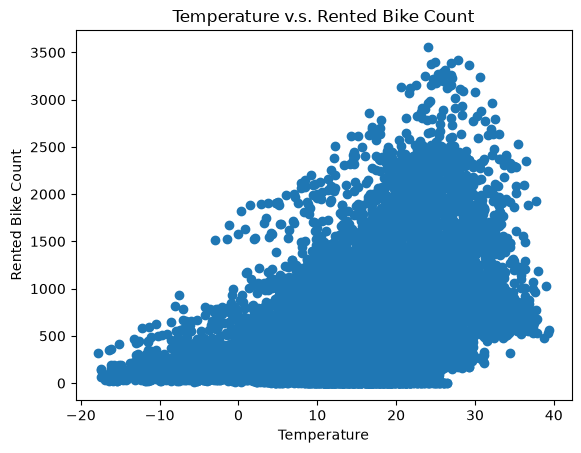

In [4]:
plt.scatter(X,Y)
plt.xlabel("Temperature")
plt.ylabel("Rented Bike Count")
plt.title("Temperature v.s. Rented Bike Count")

It looks like there is a positive, nonlinear relationship between rented bike count and temperature, which makes sense logically. There is not as much variability at lower temperatures, but variability seems to increase as temperature increases.

A straight line model would be an reasonable first model for this plot because it would capture the positive relationship. It would not be the best fit, however, as this relationship appears to be nonlinear. 

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
temp_model = LinearRegression()

temp_model.fit(
    bike[['Temperature']],
    bike[['Rented Bike Count']])

ols_b0 = temp_model.intercept_
ols_b1 = temp_model.coef_[0]

print("OLS Intercept:", ols_b0)
print("OLS Coefficient:", ols_b1)
n = len(Y)


OLS Intercept: [329.95251395]
OLS Coefficient: [29.08109899]


b1: For every degree in temperature increase, 29 more bikes are expected to be rented on average.

b0: If the temperature is 0 degrees celcius, 329 bikes are expected to be rented on average. The intercept is useful in this context because 0 degrees celcius is a plausible temperature.

If two hours' temperatures differ by 10 degrees celcius, the model predicts that the hour with the higher temperature is will experience 290 more bike rentals on average.


Part 3:

A residual expresses the difference between predicted value and actual recorded value. A positive residual means that the predicted value was lower than the actual value, and a negative residual means that the predicted value was greater than the actual value.

We square the residual after adding to get rid of negative values so that it purely represents difference and not direction. This is used instead of absolute values because absolute values are more difficult to do calculus with. The sum is also squared because this punishes predicted values that are further from the actual values.

OLS prefers model B because this problem has a smaller SSE. The smaller SSE for model B suggests that the predicted values are closer to the actual values than in model A.

No it does not. If a model has a low SSE based on training data, that does not mean that it will be able to represent new data well. A new SSE would need to be calculated with the new data.

Part 4:

The partial derivative with respect to b0 tells you how much the residual changes as a result of a change in bo. The partial derivative with respect to b1 tells you how much the residual changes as a result of a change in b1. We move in the opposite direction because if we because if we moved in one direction, the residual value would grow, and we are trying to mimimize the residual.

In [12]:
learning_rate = 1e-3

b0 = 0.0
b1 = 0.0

iterations = 10000

checkpoints = [
    0,
    1,
    5,
    10,
    25,
    50,
    100,
    250,
    500,
    1000,
    2500,
    5000,
    7500,
    10000
]

history = {
    0: {
        "b0": b0,
        "b1": b1
    }
}
mse_history = []

for i in range(1, iterations + 1):
    y_hat = b0 + b1*X
    residual = Y - y_hat

    grad_b0 = -(2 / n) * np.sum(
        residual
    )
    grad_b1 = -(2 / n) * np.sum(
        residual * X
    )
    
    mse = np.mean(residual**2)
    mse_history.append(mse)

    b0 = b0 - learning_rate * grad_b0

    b1 = b1 - learning_rate * grad_b1

    if i in checkpoints:

        history[i] = {
            "b0": b0,
            "b1": b1
        }
    


history

{0: {'b0': 0.0, 'b1': 0.0},
 1: {'b0': np.float64(1.409204109589041), 'b1': np.float64(26.45223534246575)},
 5: {'b0': np.float64(3.286205855663948),
  'b1': np.float64(42.390020522547125)},
 10: {'b0': np.float64(4.805087303080045),
  'b1': np.float64(42.670908312258234)},
 25: {'b0': np.float64(9.27728418320228), 'b1': np.float64(42.48676198480544)},
 50: {'b0': np.float64(16.59448162243757),
  'b1': np.float64(42.18087031196015)},
 100: {'b0': np.float64(30.731792822015578),
  'b1': np.float64(41.5898672907361)},
 250: {'b0': np.float64(69.4306560818216),
  'b1': np.float64(39.972081222253415)},
 500: {'b0': np.float64(123.12975102474246),
  'b1': np.float64(37.7272181856945)},
 1000: {'b0': np.float64(199.6038232058746),
  'b1': np.float64(34.530258943140375)},
 2500: {'b0': np.float64(297.32141600374496),
  'b1': np.float64(30.445225250735955)},
 5000: {'b0': np.float64(326.70782271404954),
  'b1': np.float64(29.216741637159775)},
 7500: {'b0': np.float64(329.62987628780456),
  'b

The values for b0 and b1 are recorded in the history dictionay. They are very different than the results from part 2 at lower iterations, but by the end they are nearly identical.

Text(0.5, 1.0, 'MSE by Iteration')

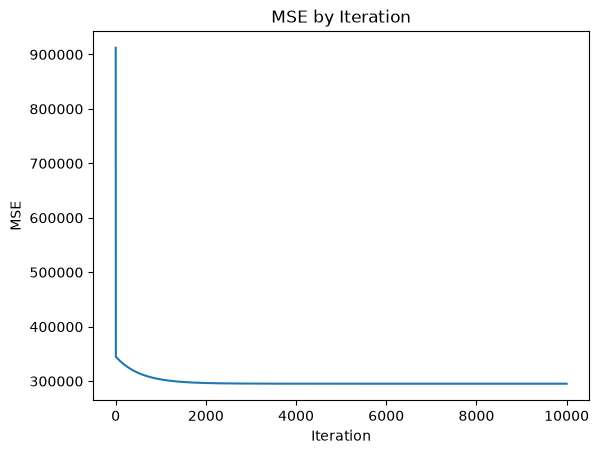

In [13]:
iter_ct = range(1, len(mse_history) + 1)

plt.plot( iter_ct, mse_history)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title("MSE by Iteration")

The loss decreases as the gradient descent runs. The flattening out of the MSE by iteration line suggests that the algorithm has converged.

If the learning rate is too large, the MSE by iteratuion line will actually diverge because steps will oershoot the minimized residual.

The multiple regression model is superior to the linear regression model because the inclusion of more variables helps to eliminate omitted variable bias. It also paints a more complete picture of factors that affect bike rental numbers other than just temperature.

In the multiple regression model, the coefficient for temperature (b1) has the same interpretation as the linear regression model. For every degree increase in temperature, bike rentals are expected to change by b1. The important distinction is that multiple regression follows multiple extra assumptions, one of those being that all other predicting variables must be assumed to be held constant.

The model will not necessarily improve just from adding more variables. At a certain point, new variables will become unnecessary and just add noise. Also, if added variables are redundant, this will cause the model to suffer from multicollinearity, which will affect the overall predicting ability of the related variables.